# 1. Imports and data load

In [5]:
import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

from sklearn.inspection import (
    permutation_importance,
    PartialDependenceDisplay
)

from PyALE import ale

In [6]:
X = pd.read_csv("../data/processed/Features_Eolico.csv")

X.head()

,Date,temperature_2m,relativehumidity_2m,dewpoint_2m,windspeed_10m,windspeed_100m,winddirection_10m,winddirection_100m,windgusts_10m,hour,dayofweek,dayofyear
0,2017-01-02T00:00:00.000000,28.5,85,24.5,1.44,1.26,146,162,1.4,0,1,2
1,2017-01-02T01:00:00.000000,28.4,86,24.7,2.06,3.99,151,158,4.4,1,1,2
2,2017-01-02T02:00:00.000000,26.8,91,24.5,1.30,2.78,148,150,3.2,2,1,2
3,2017-01-02T03:00:00.000000,27.4,88,24.3,1.30,2.69,58,105,1.6,3,1,2
4,2017-01-02T04:00:00.000000,27.3,88,24.1,2.47,4.43,58,84,4.0,4,1,2


In [7]:
preds = pd.read_csv("../data/results/Predicciones_Eolico.csv")

preds.head()

,Date,Power_AE
0,2017-01-02T00:00:00.000000,15.103733
1,2017-01-02T01:00:00.000000,13.842800
2,2017-01-02T02:00:00.000000,12.185233
3,2017-01-02T03:00:00.000000,10.660967
4,2017-01-02T04:00:00.000000,14.096667


In [8]:
X_analysis = X.copy()

X_analysis["PredictedPower"] = preds["Power_AE"]

In [9]:
X_analysis.head()

,Date,temperature_2m,relativehumidity_2m,dewpoint_2m,windspeed_10m,windspeed_100m,winddirection_10m,winddirection_100m,windgusts_10m,hour,dayofweek,dayofyear,PredictedPower
0,2017-01-02T00:00:00.000000,28.5,85,24.5,1.44,1.26,146,162,1.4,0,1,2,15.103733
1,2017-01-02T01:00:00.000000,28.4,86,24.7,2.06,3.99,151,158,4.4,1,1,2,13.842800
2,2017-01-02T02:00:00.000000,26.8,91,24.5,1.30,2.78,148,150,3.2,2,1,2,12.185233
3,2017-01-02T03:00:00.000000,27.4,88,24.3,1.30,2.69,58,105,1.6,3,1,2,10.660967
4,2017-01-02T04:00:00.000000,27.3,88,24.1,2.47,4.43,58,84,4.0,4,1,2,14.096667


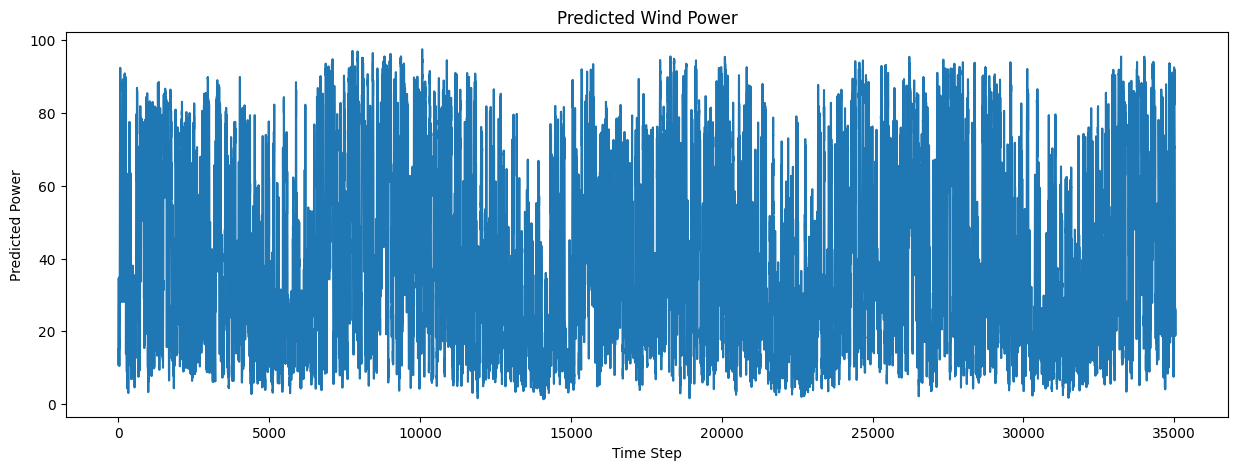

In [10]:
plt.figure(figsize=(15,5))

plt.plot(X_analysis["PredictedPower"])

plt.title("Predicted Wind Power")
plt.xlabel("Time Step")
plt.ylabel("Predicted Power")

plt.show()

In [11]:
X_analysis["PredictedPower"].describe()

count    35040.000000
mean        40.427269
std         25.230437
min          1.317567
25%         18.501925
50%         34.940650
75%         61.649325
max         97.549100
Name: PredictedPower, dtype: float64

### CORRELATION ANALYSIS

Correlation matrix

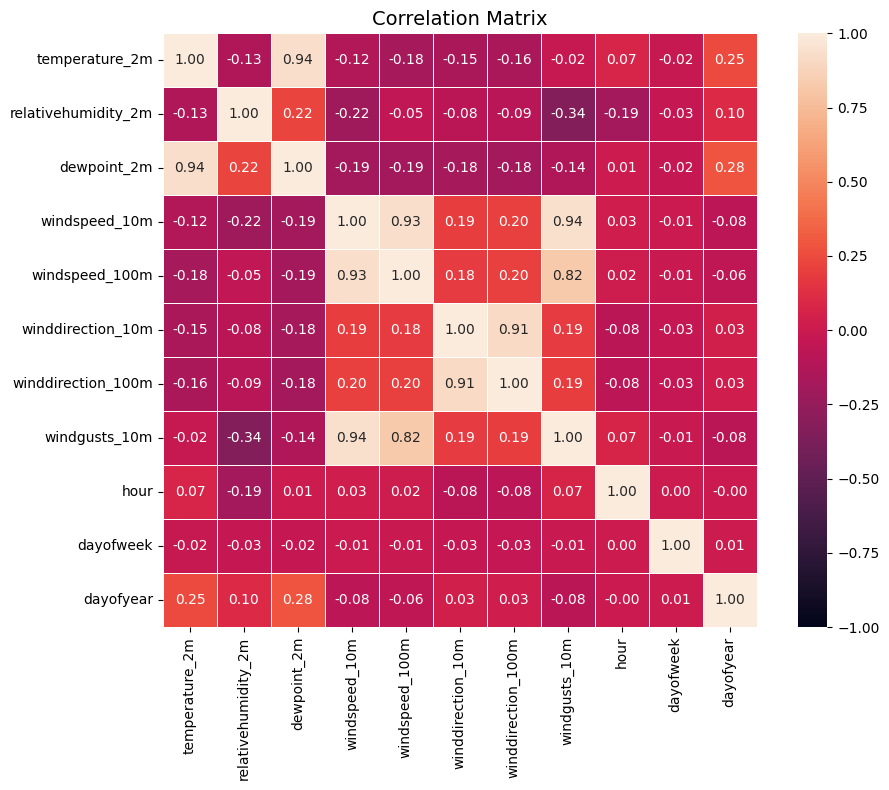

In [39]:
plt.figure(figsize=(10, 8))
M = X.drop(columns=["Date"])
# Pearson correlation matrix
corr_matrix = M.corr()

sns.heatmap(corr_matrix, 
            annot=True,    
            fmt=".2f",            
            vmax=1, vmin=-1, 
            square=True, 
            linewidths=.5)

plt.title("Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

The correlation matrix reveals two highly correlated internal blocks and one fully independent block.

The wind variables form the most problematic group. windspeed_10m and windspeed_100m are nearly redundant (r = 0.93), and windgusts_10m correlates strongly with both (r = 0.94 and 0.82 respectively). Wind direction at both heights also moves together (r = 0.91). This is the multicollinearity that makes PDP unreliable and justifies the use of ALE plots instead.

The temperature/humidity group shows a similar internal redundancy, with temperature_2m and dewpoint_2m reaching r = 0.94. However, this block is largely independent from the wind variables, meaning it contributes genuinely different information to the model.

Finally, the temporal features (hour, dayofweek, dayofyear) show near-zero correlation with everything else, confirming that they capture entirely separate patterns that no meteorological variable can replicate.

In [20]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [40]:
X_vif = M.copy()
X_vif['intercept'] = 1.0

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X.columns))]

vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

print("\n--- VIF RESULTS ---")
print(vif_data)


--- VIF RESULTS ---
                Feature          VIF
0             dayofyear  1149.304246
1   relativehumidity_2m   305.352610
2                  Date   294.780942
3        temperature_2m    38.209928
4           dewpoint_2m    26.665282
5    winddirection_100m    11.292747
6         windspeed_10m    11.052995
7     winddirection_10m     5.764589
8        windspeed_100m     5.732495
9             dayofweek     1.109409
10        windgusts_10m     1.062830
11                 hour     1.004050


To further quantify the multicollinearity observed in the correlation matrix, a Variance Inflation Factor (VIF) analysis was conducted. The results confirm that the wind-related variables, particularly windspeed_10m, windspeed_100m, and windgusts_10m, present severely inflated VIF values, well above the critical threshold of 10. Similarly, dewpoint_2m and temperature_2m show high inflation due to their strong mutual correlation. In contrast, temporal features such as hour, dayofweek, and dayofyear return low VIF scores, consistent with their near-zero correlations observed earlier.

# 2. Model load

In [12]:
model = joblib.load("../models/modelo_eolico.pkl")

X_model = X.drop(columns=["Date"])

print(model.n_estimators)
print(X_model.columns.tolist())

c:\Users\libeb\OneDrive\Documentos\GitHub\Reto04_Grupo05\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


300
['temperature_2m', 'relativehumidity_2m', 'dewpoint_2m', 'windspeed_10m', 'windspeed_100m', 'winddirection_10m', 'winddirection_100m', 'windgusts_10m', 'hour', 'dayofweek', 'dayofyear']


c:\Users\libeb\OneDrive\Documentos\GitHub\Reto04_Grupo05\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


# 3. Feature Importance (Random Forest Internal Importance)

In [13]:
rf_importance = pd.DataFrame({
    "Feature": X_model.columns,
    "Importance": model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
)

rf_importance

,Feature,Importance
4,windspeed_100m,0.354108
3,windspeed_10m,0.205059
7,windgusts_10m,0.142477
2,dewpoint_2m,0.045700
10,dayofyear,0.043638
0,temperature_2m,0.043554
6,winddirection_100m,0.042025
5,winddirection_10m,0.038960
8,hour,0.033446
1,relativehumidity_2m,0.032665


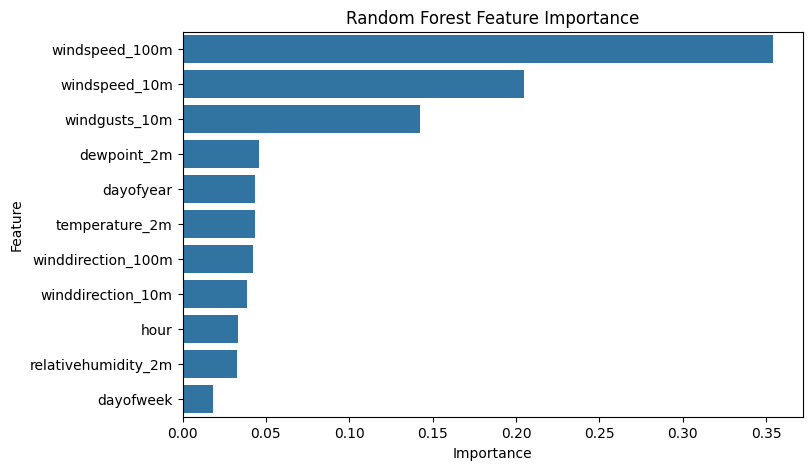

In [14]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=rf_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## Feature Importance Analysis

The Random Forest analysis shows that wind speed at 100 meters (windspeed_100m) is the most important variable, making up about 35% of the model's total weight. This makes perfect sense because the speed of the wind at turbine height is the main factor that determines how much electricity a wind turbine can generate.

Wind speed at 10 meters (windspeed_10m) and wind gusts (windgusts_10m) are the second and third most important features, at around 20.5% and 14% respectively. This shows that the model heavily relies on wind conditions closer to the ground and sudden changes in the air, which are key to predicting quick drops or jumps in power.

A middle group of features—including dew point (dewpoint_2m), day of the year (dayofyear), temperature (temperature_2m), and wind direction at both heights—all have a small but similar impact (between 3.5% and 4.5%). This tells us that the model also considers seasonal changes, wind direction, and weather factors that change air density.

On the other hand, time factors like the hour of the day (hour) and relative humidity (relativehumidity_2m) have very little influence, while the day of the week (dayofweek) matters the least (under 2%). This is logical since wind depends on natural weather patterns rather than the time on a clock or calendar days.

In conclusion, the ranking shown in the barplot proves that the model uses logical, real-world factors to make its predictions, which makes it highly reliable for managing energy in the microgrid.

# 4. PDP

## WINDSPEED 100m

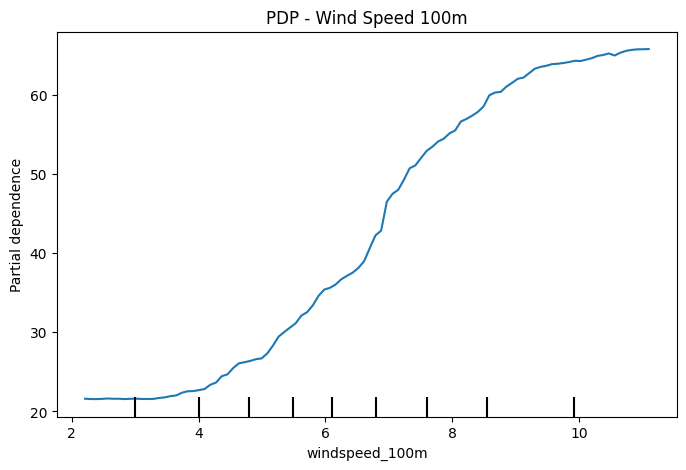

In [15]:
fig, ax = plt.subplots(figsize=(8,5))

PartialDependenceDisplay.from_estimator(
    model,
    X_model,
    features=["windspeed_100m"],
    ax=ax
)

plt.title("PDP - Wind Speed 100m")
plt.show()

### Partial Dependence Plot for Wind Speed at 100m

This Partial Dependence Plot (PDP) illustrates the marginal effect of wind speed at 100 meters (windspeed_100m) on the model's energy predictions, revealing a clear and expected nonlinear behavioral pattern.

The curve shows a strong, overall positive relationship between wind speed at 100m and the predicted power output. As the wind velocity scales up from around 3.5 m/s to 10 m/s, the partial dependence value climbs sharply from approximately 22 to over 65. This confirms that the model heavily relies on wind speed as a dominant factor to scale up its power forecasts.

The relationship is distinctly nonlinear, which perfectly reflects the real-world physics of wind turbines:

- The Flat Start (2.0 to 3.5 m/s): At very low wind speeds, the curve remains entirely flat. This accurately mirrors a turbine's cut-in speed—the threshold below which the wind is too weak to rotate the blades or generate any electricity.

- The Steep Climb (4.0 to 9.5 m/s): Once past the threshold, the curve steepens dramatically.

However, while the PDP displays a physically logical trend, its absolute reliability must be questioned due to the severe multicollinearity present in the dataset. Meteorological variables like windspeed_100m exhibit extremely high linear correlations with near-surface wind speed ($r = 0.93$) and wind gusts ($r = 0.82$). Because the PDP algorithm estimates marginal effects by assuming features are entirely independent, it forces the model to evaluate physically impossible scenarios. 

Therefore, while the general upward trend is physically sound, local explanation methods such as Accumulated Local Effects (ALE) should be considered to validate these results without the independence assumption.


## WINDSPEED 10m

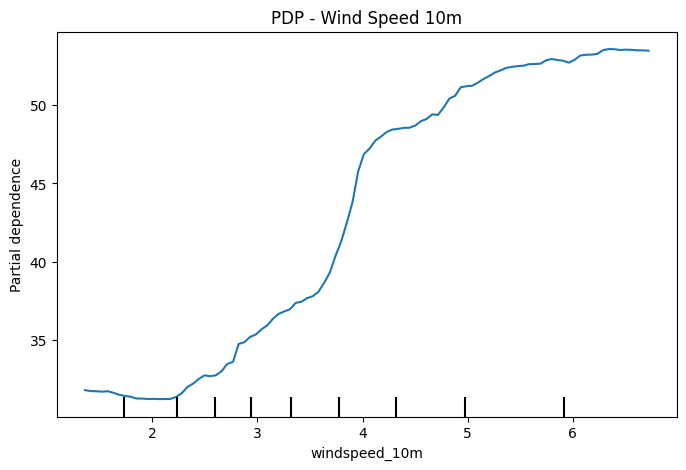

In [22]:
fig, ax = plt.subplots(figsize=(8,5))

PartialDependenceDisplay.from_estimator(
    model,
    X_model,
    features=["windspeed_10m"],
    ax=ax
)

plt.title("PDP - Wind Speed 10m")
plt.show()

### Partial Dependence Plot for Wind Speed at 10m

This Partial Dependence Plot (PDP) illustrates the marginal effect of near-surface wind speed at 10 meters (windspeed_10m) on the model's power predictions, showing a strong but highly nonlinear response curve.

As observed in the plot, the partial dependence values generally increase alongside wind velocity, rising from a baseline of approximately 31 to a peak near 54. This positive trend indicates that higher wind speeds close to the ground heavily influence the model toward predicting greater power output. The curve displays distinct operational phases that reflect real-world wind turbine dynamics:

- At very low velocities, the curve remains flat. This represents the cut-in threshold region, where wind speeds are too low to overcome mechanical friction and aerodynamic resistance, resulting in zero or baseline power generation.

- Past the initial threshold (2.2 to 4.0 m/s), the curve experiences its most dramatic, near-vertical surge, jumping from a value of 32 to 47. This sharp increase shows how sensitive the Random Forest model is to small changes within this specific wind speed range.

- As wind speeds exceed 5.5 m/s, the curve flattens significantly, stabilizing around a partial dependence value of 53. This plateau effectively captures a saturation effect, mirroring how wind turbines approach their rated power capacity where output is capped.

However, just like the 100-meter analysis, the absolute reliability of the specific thresholds must be treated with caution due to severe multicollinearity.

## WINDGUSTS 10m

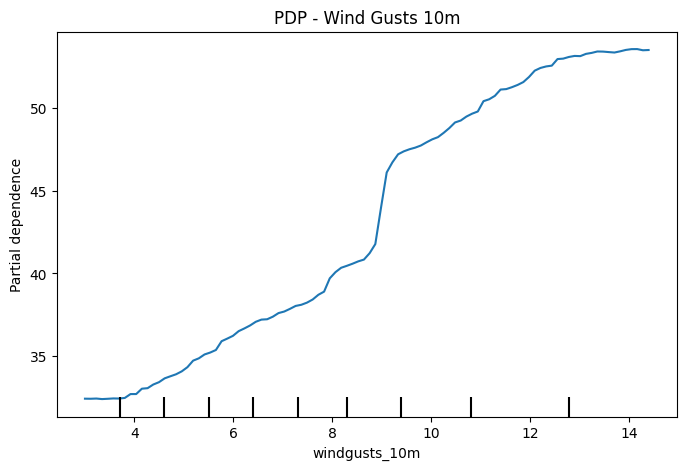

In [23]:
fig, ax = plt.subplots(figsize=(8,5))

PartialDependenceDisplay.from_estimator(
    model,
    X_model,
    features=["windgusts_10m"],
    ax=ax
)

plt.title("PDP - Wind Gusts 10m")
plt.show()

### Partial Dependence Plot for Windgusts

This Partial Dependence Plot (PDP) captures the marginal impact of near-surface wind gusts at 10 meters (windgusts_10m) on the model's power forecasts. The partial dependence value rises consistently from a baseline of approximately 32.5 to a maximum plateau near 53.5 as gust speeds increase from 3 m/s to over 14 m/s. This positive correlation indicates that the Random Forest model associates stronger atmospheric turbulence with higher expected energy output.

At the lowest recorded gust speeds, the curve remains completely flat (under 3.8 m/s). After a linear rise (around 8.5 to 9.5 m/s), the curve undergoes an abrupt, near-vertical acceleration right around the 9 m/s mark, jumping from a value of 41 to 47. At higher gust velocities, the slope flattens out entirely, stabilizing at the top of the axis (above 13 m/s).

However, just as with the previous wind velocity features, the absolute accuracy of these specific thresholds is highly vulnerable to severe multicollinearity.

## DEWPOINT 2m

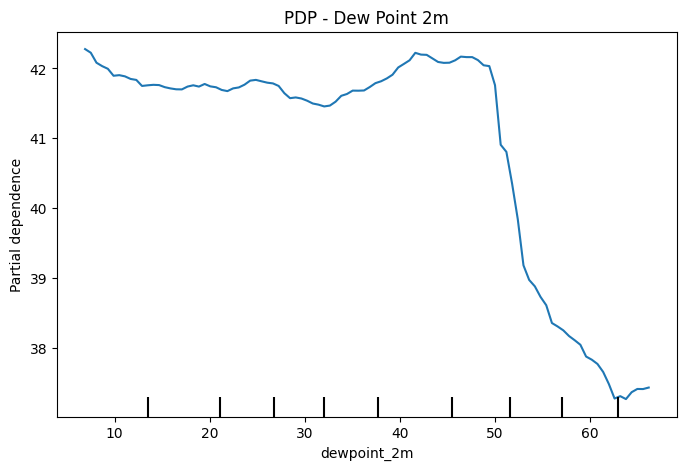

In [41]:
fig, ax = plt.subplots(figsize=(8,5))

PartialDependenceDisplay.from_estimator(
    model,
    X_model,
    features=["dewpoint_2m"],
    ax=ax
)

plt.title("PDP - Dew Point 2m")
plt.show()

### Partial Dependence Plot for DewPoint 2m

This PDP shows the marginal effect of dew point temperature (dewpoint_2m) on the model's power predictions. The curve displays two clearly distinct phases.

From roughly 8°C to 48°C, the partial dependence remains almost completely flat, hovering around 42. This plateau indicates that within this range, which covers the vast majority of observed values, dew point has virtually no independent influence on the predicted power output.

Past the 48°C mark, however, the curve drops sharply and continuously, falling from 42 down to approximately 37.5 by 65°C. This steep decline suggests that at extreme dew point values the model associates higher atmospheric moisture with lower power generation, which is physically plausible since very humid air at high temperatures can reduce air density and therefore turbine efficiency.

That said, this sharp drop must be interpreted with caution. Given the strong correlation between dewpoint_2m and temperature_2m (r = 0.94), the PDP is likely distorting the true effect by evaluating unrealistic feature combinations.

# 5. FEATURE INTERACTION

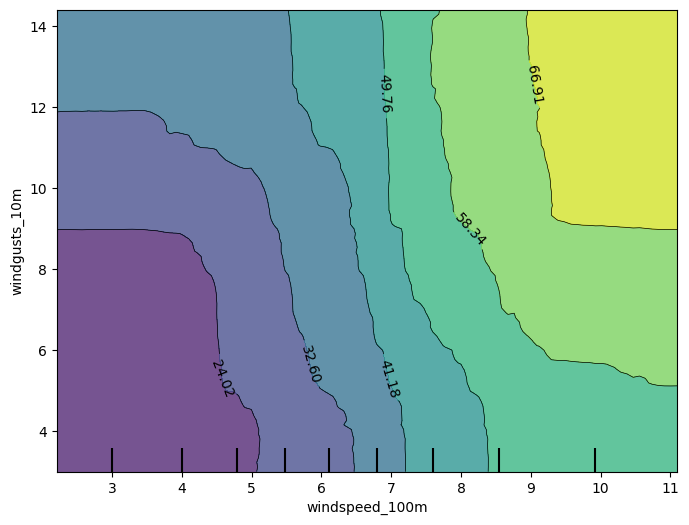

In [24]:
fig, ax = plt.subplots(figsize=(8,6))

PartialDependenceDisplay.from_estimator(
    model,
    X_model,
    features=[("windspeed_100m", "windgusts_10m")],
    ax=ax
)

plt.show()

## Feature Interaction Analysis: windspeed 100m and windgusts 10m
The interaction analysis between wind speed at 100 meters (windspeed_100m) and near-surface wind gusts at 10 meters (windgusts_10m) reveals a strong and coupled dependency between both variables when predicting power output. The influence of upper-level wind velocity on energy generation is not independent, but varies significantly depending on the turbulence and gust conditions closer to the ground.

At low values of both features, specifically when windspeed_100m is under 4 m/s and windgusts_10m is below 8 m/s, the model’s predicted production remains at its lowest baseline (around 24.02). This accurately represents a combined sub-threshold state where neither the steady wind nor the gusts possess enough kinetic energy to effectively drive the turbine.

Conversely, as both variables scale upward, the impact on the forecast becomes substantially stronger. The highest predicted generation values (exceeding 66.91, shown in the bright yellow zone) are achieved exclusively when high wind speeds at hub height (above 9 m/s) coincide with substantial gust velocities (above 9 m/s).

The contour patterns display diagonal and curved boundaries in the lower-middle region, which directly indicates the presence of a meaningful interaction effect; the contribution of the steady wind at 100m depends heavily on the atmospheric turbulence context in which it occurs. However, as wind speed at 100m dominates past 7 m/s, the contour lines become increasingly vertical, showing that upper-level wind speed remains the primary engine of power changes, while gusts provide a secondary modulating effect.

The results confirm that the Random Forest model successfully captures realistic physical interactions between these highly correlated meteorological predictors.


# 6. ALE

## WINDSPEED 100m

PyALE._ALE_generic:INFO: Continuous feature detected.


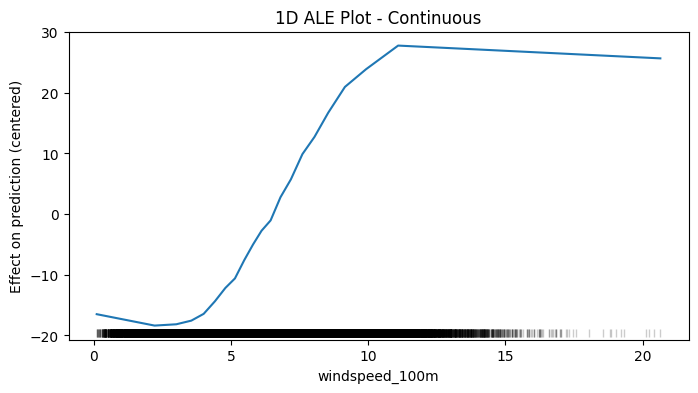

In [25]:
ale_radiation = ale(
    X=X_model,
    model=model,
    feature=["windspeed_100m"],
    include_CI=False
)

### Accumulated Local Effects for WindSpeed at 100m

This Accumulated Local Effects (ALE) plot  isolates the true impact of wind speed at 100 meters on the model's power predictions, fixing the main limitation of the Partial Dependence Plot (PDP). 

The resulting ALE curve provides a highly accurate representation of a wind turbine’s true physical response, measuring the centered net deviation from the average prediction. At low velocities up to 3.5 m/s, the curve remains flat and slightly negative, precisely capturing the mechanical cut-in speed where the wind is too weak to generate power. Past this point, the curve experiences an aggressive surge up to 11 m/s. Crucially, above 11 m/s, the ALE plot peaks and flattens into a clear plateau. This perfectly mirrors a real turbine reaching its maximum power limit, where mechanical controls cap generation to protect the system and keep it stable.

In contrast, comparing the ALE plot to the PDP highlights the danger of relying on partial dependence when severe multicollinearity is present. The PDP curve displays a narrower data window and mistakenly implies that power output continues to climb past 10 m/s without a clear operational ceiling.


## WINDSPEED 10m

PyALE._ALE_generic:INFO: Continuous feature detected.


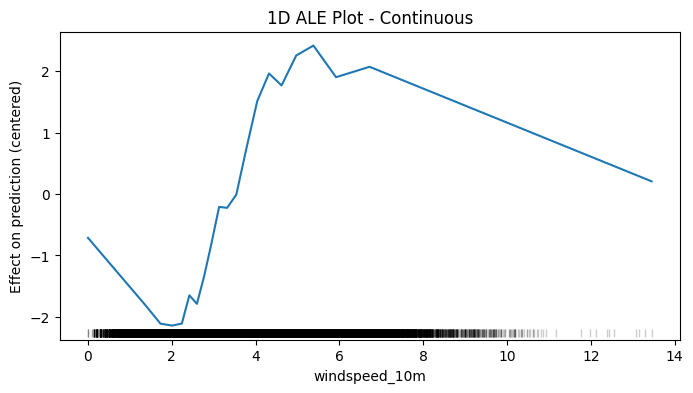

In [26]:
ale_sunshine = ale(
    X=X_model,
    model=model,
    feature=["windspeed_10m"],
    include_CI=False
)

### Accumulated Local Effects for Wind Speed at 10m

The ALE plot for wind speed at 10 meters isolates the true impact of near-surface wind by using only real-world data intervals. This completely removes the mathematical bias that ruins the Partial Dependence Plot.

The ALE curve reveals a precise behavioral pattern centered around zero. Below 2 m/s, it shows a negative effect that bottoms out near -2.1, capturing the cut-in threshold where winds are too weak to help. Between 2.2 m/s and 5.5 m/s, the curve climbs rapidly to a peak of +2.4 as wind power increases. Crucially, past 5.5 m/s, the ALE plot turns downward, showing that once surface winds get too high, their independent contribution actually drops when upper-air speeds are already accounted for.

In contrast, the PDP is highly misleading due to these strong correlations. It shows a continuous, smooth climb that plateaus near 54, completely missing the sudden peak and drop captured by ALE.

## WINDGUSTS 10m

PyALE._ALE_generic:INFO: Continuous feature detected.


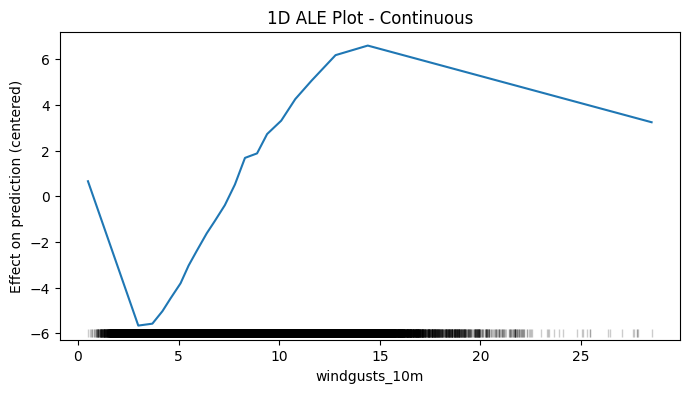

In [27]:
ale_sunshine = ale(
    X=X_model,
    model=model,
    feature=["windgusts_10m"],
    include_CI=False
)

### Accumulated Local Effects for Wind Gusts at 10m

The ALE plot for wind gusts at 10 meters provides an uncorrupted look at how sudden wind variations independently affect the model's predictions. Just like the previous features, the PDP for wind gusts suffers from severe mathematical bias due to multicollinearity.

The ALE curve reveals a sharp, non-linear pattern centered around zero. Below 3.5 m/s, it shows a negative trend that bottoms out near -5.6, capturing the baseline threshold where gusts are too weak to contribute to generation. Between 4 m/s and 14.5 m/s, the curve climbs aggressively to a peak of +6.5 as stronger gusts directly drive higher power output. Crucially, past 14.5 m/s, the ALE plot turns downward, showing that once atmospheric turbulence becomes too extreme, its independent contribution drops, which aligns with real-world turbine safety limits that cap generation during high-velocity gusts. In contrast, the PDP is highly misleading because it completely misses this late-stage drop.

## DEWPOINT 2m

PyALE._ALE_generic:INFO: Continuous feature detected.


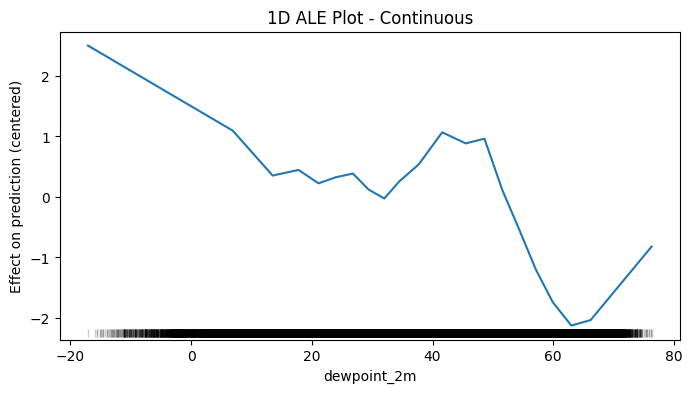

In [42]:
ale_sunshine = ale(
    X=X_model,
    model=model,
    feature=["dewpoint_2m"],
    include_CI=False
)

### Accumulated Local Effects for Dew Point at 2m

The ALE plot reveals a markedly different picture from the PDP, and a much more physically informative one.

At low dew point values (below -10°C), the curve starts at its highest point (~+2.5), meaning cold, dry air conditions independently push predictions upward. This aligns with the fact that denser, colder air carries more kinetic energy and improves turbine efficiency. As dew point rises from -10°C to around 20°C, the effect drops steadily toward zero, indicating a gradual loss of this density advantage.

Between 20°C and 45°C the curve fluctuates around zero, suggesting that within this mid-range the independent contribution of dew point is essentially neutral.

Past 45°C, the curve plunges sharply to a minimum near -2.2 around 62°C, before partially recovering toward -0.8 at the extreme right tail. This negative region confirms that very high dew point values, indicating hot, saturated air, genuinely reduce the model's predicted output, consistent with lower air density under humid conditions.

Comparing this to the PDP, the ALE tells a richer and more reliable story: the effect is not simply a flat plateau followed by a late drop, but a continuous negative trend driven by real atmospheric physics, free from the distortion caused by multicollinearity.

# 7. PERMUTATION IMPORTANCE

In [33]:
df_real = pd.read_csv("../data/raw/DatosEolicos.csv")

df_real["Date"] = pd.to_datetime(df_real["Date"])

df_real["hour"] = df_real["Date"].dt.hour
df_real["dayofweek"] = df_real["Date"].dt.dayofweek
df_real["dayofyear"] = df_real["Date"].dt.dayofyear

In [34]:
features = [
    "temperature_2m",
    "relativehumidity_2m",
    "dewpoint_2m",
    "windspeed_10m",
    "windspeed_100m",
    "winddirection_10m",
    "winddirection_100m",
    "windgusts_10m",
    "hour",
    "dayofweek",
    "dayofyear"
]

X_real = df_real[features]

y_real = df_real["Power"]

In [36]:
from sklearn.inspection import permutation_importance

pfi = permutation_importance(
    model,
    X_real,
    y_real,
    n_repeats=20,
    random_state=42,
    n_jobs=1
)

In [37]:
pfi_df = pd.DataFrame({
    "Feature": X_real.columns,
    "Importance": pfi.importances_mean,
    "Std": pfi.importances_std
})

pfi_df = pfi_df.sort_values(
    "Importance",
    ascending=False
)

pfi_df

,Feature,Importance,Std
4,windspeed_100m,0.628518,0.003276
3,windspeed_10m,0.167049,0.000732
7,windgusts_10m,0.153553,0.000726
2,dewpoint_2m,0.080751,0.000468
0,temperature_2m,0.079130,0.000469
8,hour,0.078528,0.000776
10,dayofyear,0.077770,0.000402
6,winddirection_100m,0.074814,0.000481
5,winddirection_10m,0.064683,0.000333
1,relativehumidity_2m,0.046436,0.000341


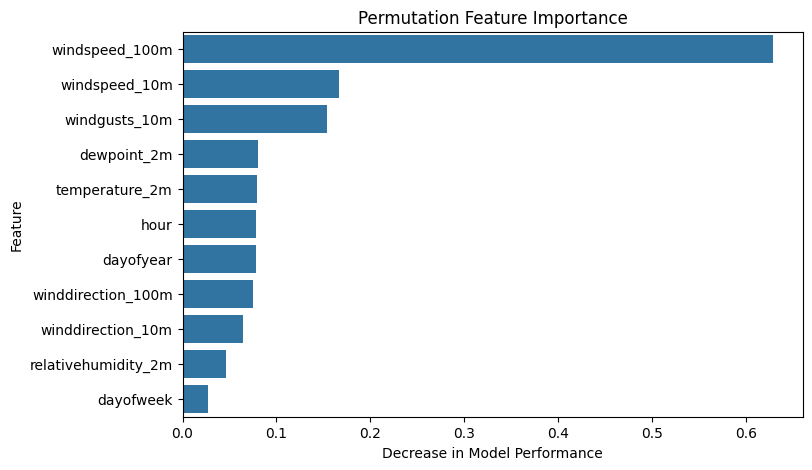

In [38]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=pfi_df,
    x="Importance",
    y="Feature"
)

plt.title("Permutation Feature Importance")
plt.xlabel("Decrease in Model Performance")
plt.ylabel("Feature")

plt.show()

## Permutation Feature Importance Analysis

To evaluate the contribution of each feature to the predictive performance of the model, a Permutation Feature Importance analysis was conducted. The results clearly demonstrate that wind speed at 100 meters is by far the most influential variable, generating the sharpest degradation in model accuracy when its values are shuffled.

Wind speed at 10 meters and wind gusts emerge as the next most significant predictors. This strong predominance of wind-related metrics underscores their critical role in the model's forecasting capabilities, which aligns perfectly with the physical nature of wind energy generation.

A secondary cluster of features—including dew point, temperature, hour of the day, day of the year, and wind direction at 100 meters, shows a moderate and remarkably uniform level of importance. This indicates that atmospheric thermodynamics, wind orientation, and temporal context all contribute equally to refining the model's predictions. Conversely, wind direction at 10 meters and relative humidity present a slightly lower impact.

Finally, the day of the week exhibits a negligible contribution to the model's performance. This minimal impact is consistent with expectations, as institutional calendar cycles do not influence physical meteorological phenomena. Overall, the permutation analysis validates that the model relies on highly logical and physically meaningful predictors.

# FINAL CONCLUSION

This interpretability analysis of the wind power prediction Random Forest model yields several robust and physically consistent findings across all applied methods.

Wind speed at 100 meters is the dominant predictor. Every technique, internal feature importance (~35%), permutation importance, PDPs, and ALE plots, consistently places windspeed_100m at the top. This is physically coherent: it is the variable closest to actual turbine hub height, and therefore the most direct driver of power generation.

Surface wind variables play a strong but secondary role. windspeed_10m and windgusts_10m consistently rank second and third across all methods. Notably, their ALE plots show that at very high values their independent contribution drops, a real-world safety cutoff effect that the PDP completely misses.

Multicollinearity is critical for PDP-based analysis. The dataset contains severe linear correlations among wind features (r = 0.93 between windspeed_100m and windspeed_10m). PDP plots, which assume feature independence, produce mathematically biased curves. ALE plots, by operating on local intervals within the actual data distribution, provide a far more trustworthy picture of each feature's true marginal effect, including the saturation plateaus and post-peak drops that PDPs miss entirely.

The interaction between windspeed_100m and windgusts_10m is meaningful but asymmetric. The PDP interaction plot confirms that maximum predicted power requires both features to be simultaneously high. However, once windspeed_100m exceeds ~7 m/s, it increasingly dominates the prediction, with gusts acting only as a secondary modulating factor.

Temporal and meteorological context provides modest but consistent additional value. Features such as dewpoint_2m, temperature_2m, dayofyear, and wind direction contribute uniformly at a moderate level (~3.5–4.5% internal importance). These variables capture seasonal cycles and air density effects. By contrast, hour and dayofweek contribute very little, confirming that wind patterns follow atmospheric cycles rather than social or institutional schedules.

Overall model validity is strong. The logical ranking of predictors across all methods consistently reflects the physics of wind energy. This cross-method convergence is the most important signal: the model is not overfitting to statistical artefacts but learning from physically meaningful structure in the data. It is therefore suitable for deployment in a microgrid energy management context, where reliable wind power forecasting has direct operational consequences.